# Exploratory Data Analysis

---
## Setup

In [27]:
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
from tqdm import tqdm
 
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110})

PROJECT_ROOT = Path().resolve().parent
 
with open(PROJECT_ROOT / "configs" / "data_config.yaml") as f:
    CFG = yaml.safe_load(f)
 
def _ds_path(name_key: str) -> Path:
    ds = CFG["datasets"][name_key]
    suffix = CFG["datasets"].get("merged", {}).get("suffix", "-YOLO")
    folder = ds["name"] + (suffix if name_key == "merged" else "-YOLO")
    return PROJECT_ROOT / CFG["paths"]["out"] / folder
 
DATASETS = {
    "Angelina":     _ds_path("angelina"),
    "NaturalScene": _ds_path("natural_scene"),
    "DSBI":         _ds_path("dsbi"),
    "Merged":       _ds_path("merged"),
}
 
SPLITS       = CFG["detector"]["splits"]
SOURCE_NAMES = ["Angelina", "NaturalScene", "DSBI"]
DS_ORDER     = SOURCE_NAMES + ["Merged"]
 
MERGED_PREFIX = {
    CFG["datasets"]["angelina"]["prefix"]:      "Angelina",
    CFG["datasets"]["natural_scene"]["prefix"]: "NaturalScene",
    CFG["datasets"]["dsbi"]["prefix"]:          "DSBI",
}
 
PALETTE   = dict(zip(SPLITS, ["#4C72B0", "#DD8452", "#55A868"]))
DS_COLORS = dict(zip(SOURCE_NAMES, ["#4C72B0", "#DD8452", "#55A868"]))
 
BOXPLOT_KW = dict(
    order=SPLITS, hue="split", hue_order=SPLITS,
    palette=PALETTE, legend=False,
    flierprops={"marker": ".", "markersize": 2, "alpha": 0.3},
)
 
with open(DATASETS["Merged"] / "data.yaml") as f:
    CLASS_NAMES = yaml.safe_load(f)["names"]

### Utility Functions

In [28]:
def count_images(dataset_path: Path) -> dict:
    """Image counts per split (and total) for a YOLO dataset directory."""
    counts = {
        sp: len(list((dataset_path / "images" / sp).glob("*")))
        for sp in SPLITS
        if (dataset_path / "images" / sp).exists()
    }
    counts["total"] = sum(counts.values())
    return counts
 
 
def parse_annotations(dataset_name: str, dataset_path: Path) -> pd.DataFrame:
    """Parse all YOLO label files → flat DataFrame of bounding boxes."""
    records = []
    for split in SPLITS:
        label_dir = dataset_path / "labels" / split
        if not label_dir.exists():
            continue
        for lf in tqdm(label_dir.glob("*.txt"), desc=f"{dataset_name}/{split}", leave=False):
            lines = lf.read_text().splitlines()
            for line in lines:
                parts = line.split()
                if len(parts) < 5:
                    continue
                cls, xc, yc, w, h = map(float, parts[:5])
                records.append({
                    "dataset": dataset_name, "split": split, "image_id": lf.stem,
                    "class_id": int(cls), "xc": xc, "yc": yc,
                    "bbox_width": w, "bbox_height": h,
                })
    return pd.DataFrame(records)
 
 
def source_from_prefix(image_id: str) -> str | None:
    """Map a MergedDataset image_id to its original source dataset name."""
    return next((src for pfx, src in MERGED_PREFIX.items() if image_id.startswith(pfx)), None)
 
 
def count_merged_by_source(split: str | None = None) -> pd.Series:
    """Count images per source inside MergedDataset (by filename prefix)."""
    counts = {src: 0 for src in SOURCE_NAMES}
    splits = [split] if split else SPLITS
    for sp in splits:
        img_dir = DATASETS["Merged"] / "images" / sp
        if not img_dir.exists():
            continue
        for p in img_dir.glob("*"):
            src = source_from_prefix(p.name)
            if src:
                counts[src] += 1
    return pd.Series(counts, name="In Merged")
 
 
def stacked_bar(data: pd.DataFrame, title: str, ylabel: str, ax=None) -> None:
    """Stacked bar chart of split counts with the shared palette."""
    standalone = ax is None
    if standalone:
        _, ax = plt.subplots(figsize=(8, 4))
    data.reindex(DS_ORDER)[SPLITS].plot(
        kind="bar", stacked=True, ax=ax,
        color=[PALETTE[s] for s in SPLITS], edgecolor="none", width=0.6,
    )
    ax.set(title=title, xlabel="", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Split")
    if standalone:
        plt.tight_layout(); plt.show()

### Data Loading

In [29]:
image_stats_df = pd.DataFrame(
    {name: count_images(path) for name, path in DATASETS.items()}
).T
 
ann_df = pd.concat(
    [parse_annotations(name, path) for name, path in DATASETS.items()],
    ignore_index=True,
)
ann_df["area"]         = ann_df["bbox_width"] * ann_df["bbox_height"]
ann_df["aspect_ratio"] = ann_df["bbox_width"] / ann_df["bbox_height"]
ann_df["min_side"]     = ann_df[["bbox_width", "bbox_height"]].min(axis=1)

Angelina/train: 0it [00:00, ?it/s]

---
## 1. Dataset Composition

In [30]:
char_counts = (
    ann_df.groupby(["dataset", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SPLITS, fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
)
 
composition = pd.concat(
    [image_stats_df, char_counts], axis=1, keys=["Images", "Characters"]
).reindex(DS_ORDER)
composition

Images                 Characters                      
              train  val test total      train    val   test   total
Angelina        225   46   50   321      55470  13528  13013   82011
NaturalScene    740  185  232  1157       3321    840    979    5140
DSBI             42   10  176   228      15226   4809  71220   91255
Merged         3771  236  370  4377      78862  16734  49636  145232

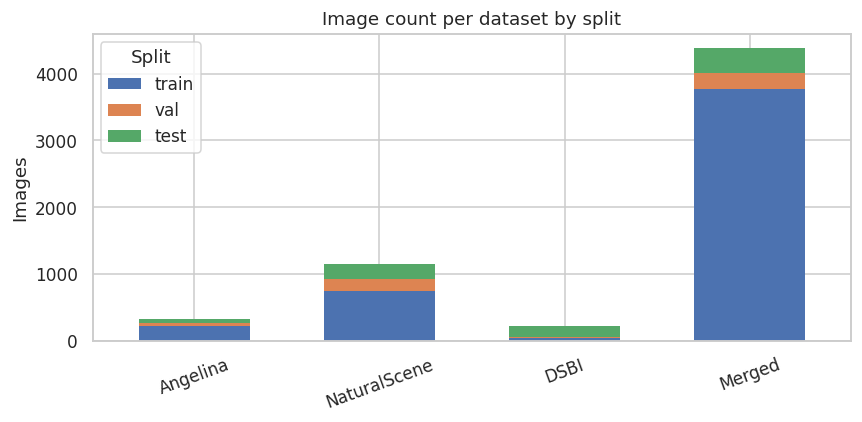

In [31]:
stacked_bar(image_stats_df, "Image count per dataset by split", "Images")

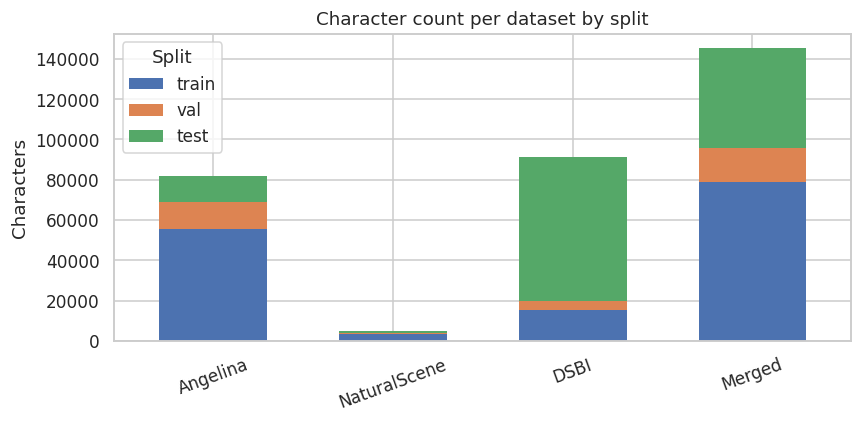

In [32]:
stacked_bar(
    ann_df.groupby(["dataset", "split"]).size().unstack(fill_value=0),
    "Character count per dataset by split", "Characters",
)

In [33]:
_train = ann_df[ann_df.split == "train"]
 
dsbi_recto_mask = _train.image_id.str.contains("+recto", regex=False)
src_train = {
    "Angelina":     _train[_train.dataset == "Angelina"],
    "NaturalScene": _train[_train.dataset == "NaturalScene"],
    "DSBI":         _train[(_train.dataset == "DSBI") & dsbi_recto_mask],
}
 
dsbi_recto_count = sum(
    "+recto" in p.name
    for p in (DATASETS["DSBI"] / "images" / "train").glob("*")
)
 
mrg_train = _train[_train.dataset == "Merged"].copy()
mrg_train["source"] = mrg_train["image_id"].map(source_from_prefix)
 
orig_images = pd.Series(
    {src: (image_stats_df.loc[src, "train"] if src != "DSBI" else dsbi_recto_count)
     for src in SOURCE_NAMES},
    name="images (original)",
)
 
oversample = pd.concat([
    orig_images,
    count_merged_by_source("train").rename("images in Merged"),
    pd.Series({src: len(df) for src, df in src_train.items()}, name="chars (original)"),
    mrg_train.groupby("source").size().rename("chars in Merged"),
    pd.Series(
        {src: df.groupby("image_id").size().median() for src, df in src_train.items()},
        name="median chars/img",
    ).round(1),
], axis=1)
 
oversample["oversampling (×)"] = (
    oversample["images in Merged"] / oversample["images (original)"]
).round(2)
oversample

,images (original),images in Merged,chars (original),chars in Merged,median chars/img,oversampling (×)
Angelina,225,225,55470,55470,308.0,1.00
NaturalScene,740,3525,3321,15775,4.0,4.76
DSBI,21,21,7617,7617,475.5,1.00


---
## 2. Class Imbalance

In [34]:
merged_df  = ann_df[ann_df.dataset == "Merged"]
split_cc   = merged_df.groupby(["split", "class_id"]).size().unstack(fill_value=0)
 
imbalance_summary = pd.DataFrame([
    {
        "split":           sp,
        "classes present": f"{int((v := split_cc.loc[sp].values.astype(float))[v > 0].size)} / 63",
        "min":             int(v[v > 0].min()),
        "max":             int(v.max()),
        "mean":            int(v.mean()),
        "median":          int(np.median(v)),
    }
    for sp in SPLITS if sp in split_cc.index
]).set_index("split")
imbalance_summary
 

,classes present,min,max,mean,median
split,,,,,
train,63 / 63,55,6288,1251,785
val,63 / 63,8,1354,265,111
test,63 / 63,24,2667,787,603


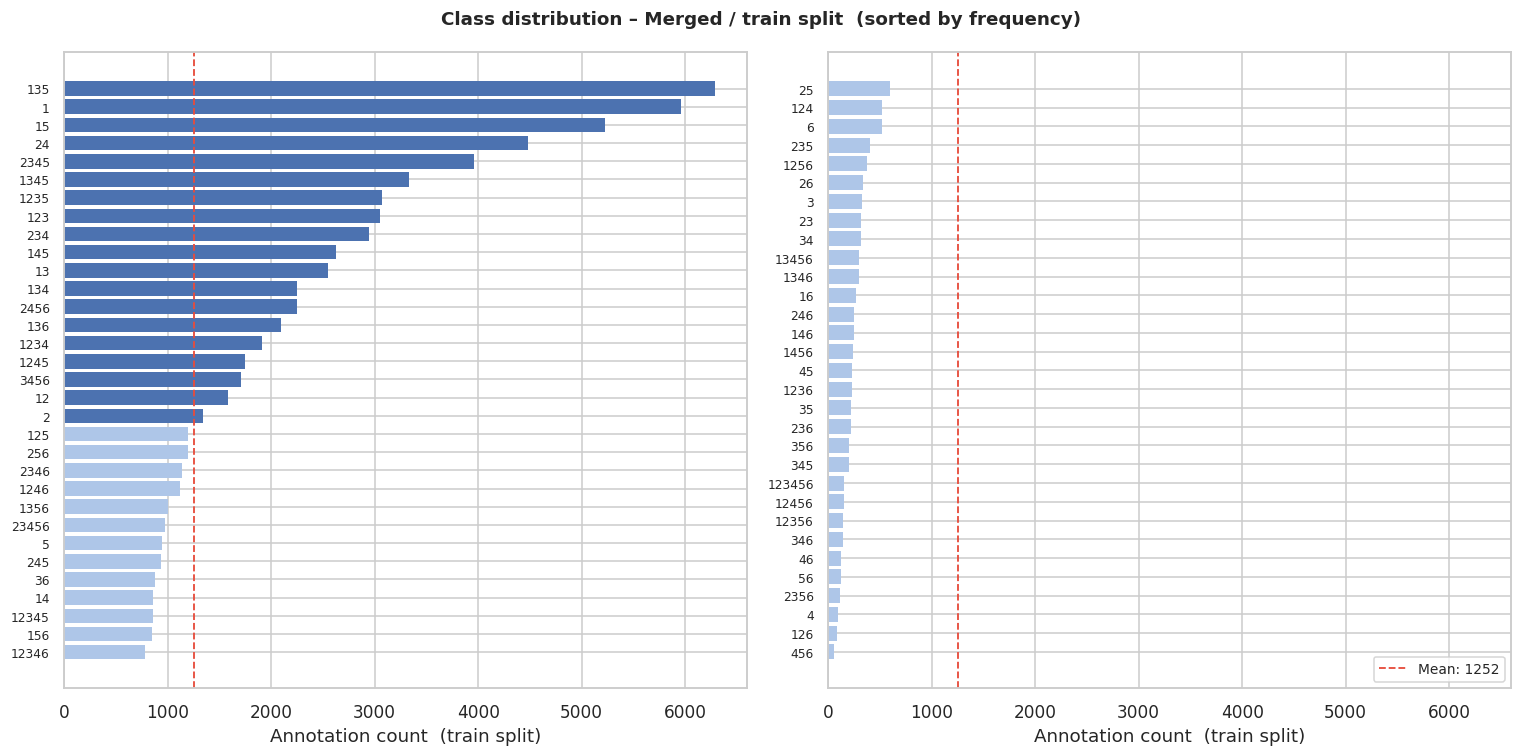

In [35]:
train_cc   = split_cc.loc["train"].rename(index=lambda i: CLASS_NAMES[i]).sort_values()
mean_train = train_cc.mean()
bar_colors = ["#4C72B0" if v >= mean_train else "#AEC6E8" for v in train_cc]
 
mid    = len(train_cc) // 2
halves = [train_cc.iloc[mid:], train_cc.iloc[:mid]]
colors = [bar_colors[mid:],    bar_colors[:mid]]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)
for i, (ax, cc, clr) in enumerate(zip(axes, halves, colors)):
    ax.barh(cc.index, cc.values, color=clr, edgecolor="none")
    ax.axvline(mean_train, color="#E74C3C", linestyle="--", linewidth=1.2,
               label=f"Mean: {mean_train:.0f}" if i == 1 else "_nolegend_")
    ax.set_xlabel("Annotation count  (train split)")
    ax.tick_params(axis="y", labelsize=8)
 
axes[1].legend(fontsize=9, loc="lower right")
plt.suptitle("Class distribution – Merged / train split  (sorted by frequency)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

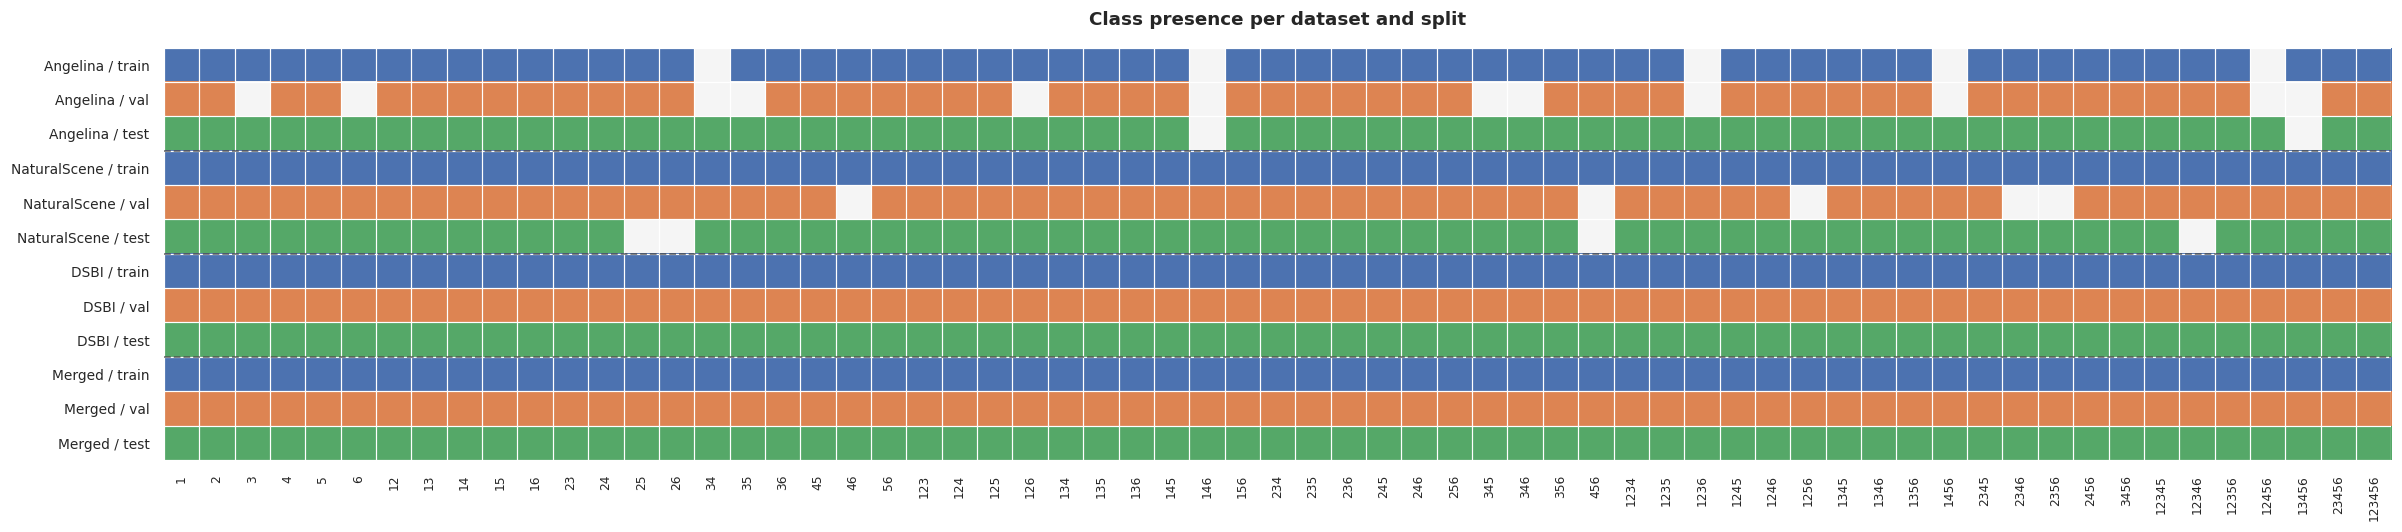

In [36]:
rows, row_labels = [], []
for ds in DS_ORDER:
    for sp in SPLITS:
        present = set(ann_df.loc[(ann_df.dataset == ds) & (ann_df.split == sp), "class_id"])
        rows.append([int(i in present) for i in range(63)])
        row_labels.append(f"{ds} / {sp}")
 
presence = pd.DataFrame(rows, index=row_labels, columns=CLASS_NAMES)
n_rows, n_cols = presence.shape
 
img_data = np.full((n_rows, n_cols, 4), mcolors.to_rgba("#f5f5f5"))
for i, label in enumerate(row_labels):
    sp = label.split(" / ")[1]
    img_data[i, presence.iloc[i].values.astype(bool)] = mcolors.to_rgba(PALETTE[sp])
 
fig, ax = plt.subplots(figsize=(22, 5))
ax.grid(False)
ax.imshow(img_data, aspect="auto", interpolation="nearest")
 
for sep in [2.5, 5.5, 8.5]:
    ax.axhline(sep, color="#444", linewidth=1.2, linestyle="--", alpha=0.7)
 
for which in ("x", "y"):
    ax.set_ticks_minor(
        np.arange(-0.5, (n_cols if which == "x" else n_rows), 1),
        axis=which, minor=True,
    ) if False else None
 
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)
 
ax.set_xticks(range(n_cols)); ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=8)
ax.set_yticks(range(n_rows)); ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title("Class presence per dataset and split", fontsize=12, pad=15, fontweight="bold")
plt.tight_layout(); plt.show()

---
## 3. Bounding Box Geometry

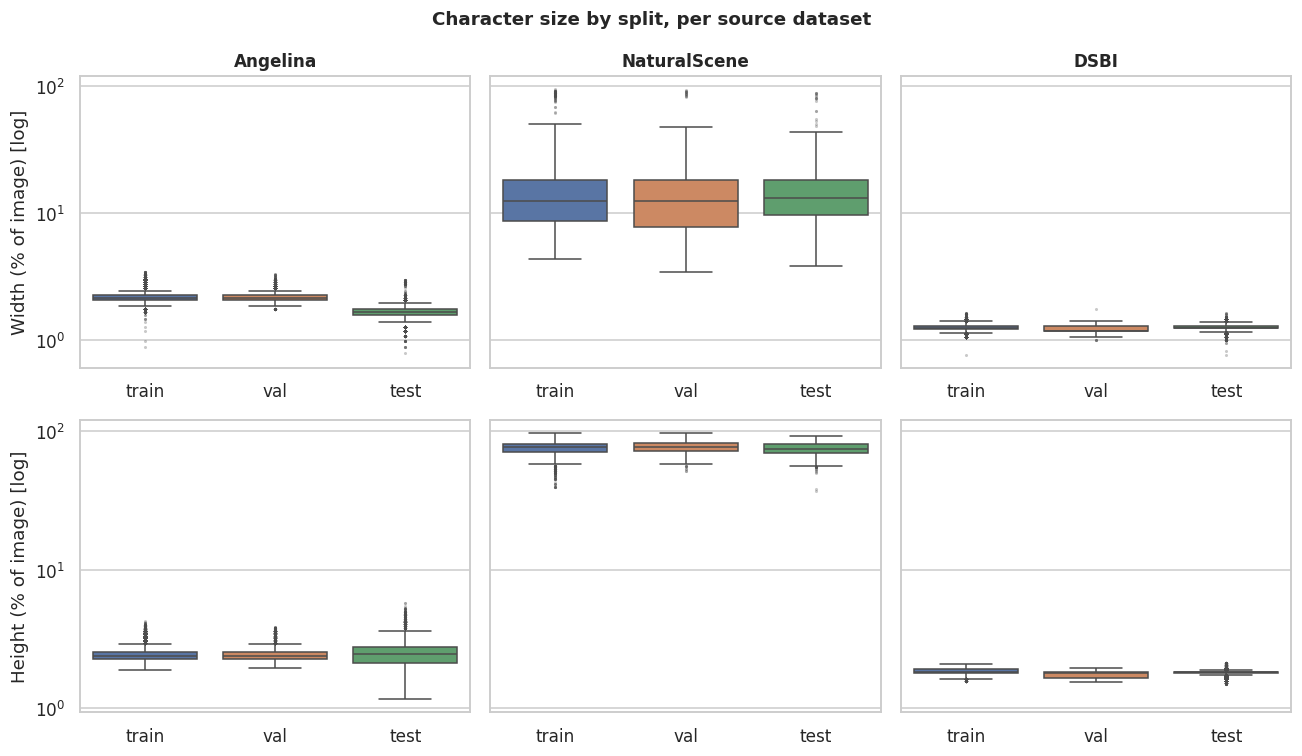

In [37]:
src_df = ann_df[ann_df.dataset.isin(SOURCE_NAMES)].assign(
    width_pct=lambda d: d.bbox_width * 100,
    height_pct=lambda d: d.bbox_height * 100,
)
 
metrics = [
    ("width_pct",  "Width (% of image) [log]"),
    ("height_pct", "Height (% of image) [log]"),
]
 
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey="row")
for col, ds in enumerate(SOURCE_NAMES):
    ds_data = src_df[src_df.dataset == ds]
    for row, (metric, ylabel) in enumerate(metrics):
        ax = axes[row, col]
        sns.boxplot(data=ds_data, x="split", y=metric, ax=ax, **BOXPLOT_KW)
        ax.set_yscale("log")
        ax.set(xlabel="", ylabel=ylabel if col == 0 else "")
        if row == 0:
            ax.set_title(ds, fontsize=11, fontweight="bold")
 
plt.suptitle("Character size by split, per source dataset", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

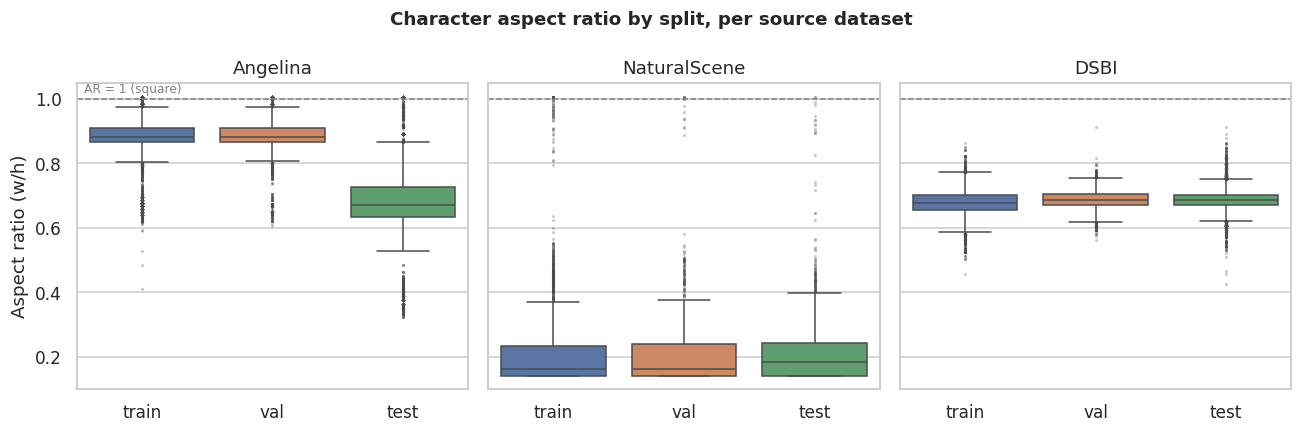

In [38]:
ar_clip_bounds = ann_df.loc[ann_df.dataset.isin(SOURCE_NAMES), "aspect_ratio"].quantile([0.01, 0.99])
 
ar_src = (
    ann_df[ann_df.dataset.isin(SOURCE_NAMES)]
    .assign(aspect_ratio=lambda d: d.aspect_ratio.clip(*ar_clip_bounds))
)
 
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for col, (ax, ds) in enumerate(zip(axes, SOURCE_NAMES)):
    sns.boxplot(data=ar_src[ar_src.dataset == ds], x="split", y="aspect_ratio",
                ax=ax, **BOXPLOT_KW)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.0)
    ax.set(title=ds, xlabel="", ylabel="Aspect ratio (w/h)" if col == 0 else "")
 
axes[0].annotate("AR = 1 (square)", xy=(0.02, 1.02), xycoords=("axes fraction", "data"),
                 color="gray", fontsize=8)
plt.suptitle("Character aspect ratio by split, per source dataset",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

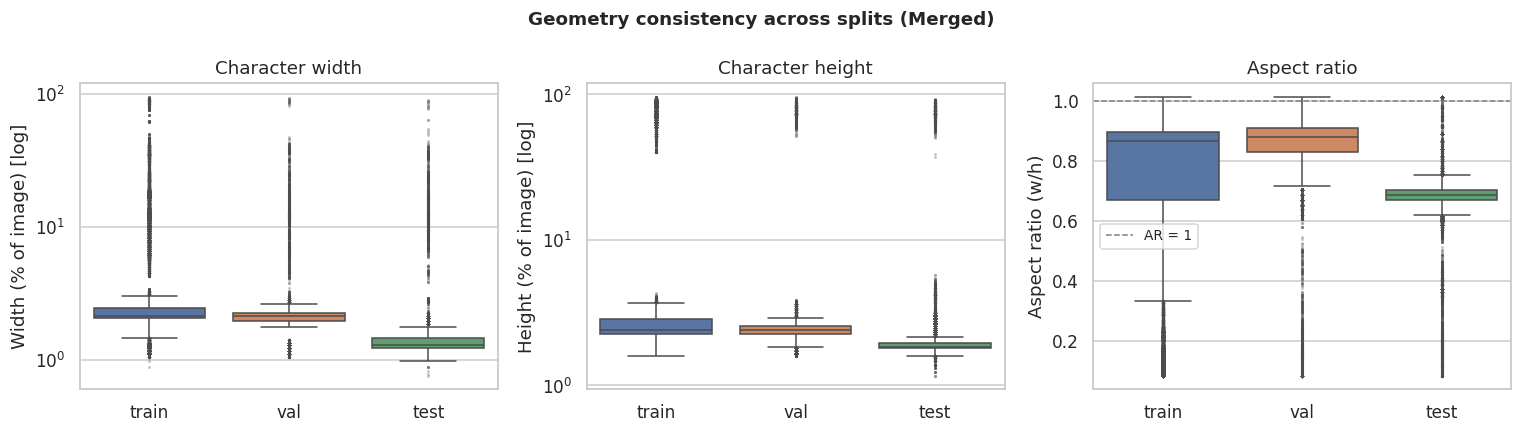

In [39]:
q01, q99 = ann_df.loc[ann_df.dataset == "Merged", "aspect_ratio"].quantile([0.01, 0.99])
 
mrg_df = ann_df[ann_df.dataset == "Merged"].assign(
    width_pct=lambda d: d.bbox_width * 100,
    height_pct=lambda d: d.bbox_height * 100,
    ar_clip=lambda d: d.aspect_ratio.clip(lower=q01, upper=q99),
)
 
panels = [
    ("width_pct",  "Width (% of image) [log]",  "Character width",  True),
    ("height_pct", "Height (% of image) [log]", "Character height", True),
    ("ar_clip",    "Aspect ratio (w/h)",         "Aspect ratio",     False),
]
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, ylabel, title, log_scale) in zip(axes, panels):
    sns.boxplot(data=mrg_df, x="split", y=col, ax=ax, **BOXPLOT_KW)
    ax.set(xlabel="", ylabel=ylabel, title=title)
    if log_scale:
        ax.set_yscale("log")
 
axes[2].axhline(1.0, color="gray", linestyle="--", linewidth=1.0, label="AR = 1")
axes[2].legend(fontsize=9)
plt.suptitle("Geometry consistency across splits (Merged)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

---
## 4. Tiny-Object & Feature-Map Analysis

In [40]:
INPUT_SIZES = [640, 800, 960, 1024, 1280]
STRIDES     = [4, 8, 16, 32]
 
mrg = ann_df[ann_df.dataset == "Merged"].copy()
 
rows = []
for inp in INPUT_SIZES:
    obj_px = mrg["min_side"] * inp
    for stride in STRIDES:
        cells = obj_px / stride
        rows.append({
            "input_size": inp,
            "stride":     stride,
            "median_px":  round(obj_px.median(), 2),
            "p25_px":     round(obj_px.quantile(0.25), 2),
            "p10_px":     round(obj_px.quantile(0.10), 2),
            "median_cells": round(cells.median(), 3),
            "pct_lt1_cell": round((cells < 1).mean() * 100, 2),
            "pct_lt2_cell": round((cells < 2).mean() * 100, 2),
            "pct_lt3_cell": round((cells < 3).mean() * 100, 2),
        })
 
fm_df = pd.DataFrame(rows)
fm_df

,input_size,stride,median_px,p25_px,p10_px,median_cells,pct_lt1_cell,pct_lt2_cell,pct_lt3_cell
0,640,4,13.13,8.26,7.87,3.281,0.00,19.75,42.64
1,640,8,13.13,8.26,7.87,1.641,19.75,85.28,87.89
2,640,16,13.13,8.26,7.87,0.820,85.28,88.14,89.95
3,640,32,13.13,8.26,7.87,0.410,88.14,91.94,95.38
4,800,4,16.41,10.33,9.84,4.102,0.00,0.02,33.51
5,800,8,16.41,10.33,9.84,2.051,0.02,48.48,87.61
6,800,16,16.41,10.33,9.84,1.025,48.48,87.89,88.65
7,800,32,16.41,10.33,9.84,0.513,87.89,90.40,93.39
8,960,4,19.69,12.39,11.80,4.922,0.00,0.00,19.75
9,960,8,19.69,12.39,11.80,2.461,0.00,36.87,85.28


In [41]:
REF_INPUT = 800
obj_px = mrg["min_side"] * REF_INPUT
 
threshold_summary = pd.DataFrame({
    "threshold_px": [6, 8, 10, 12, 16, 20, 24],
    "pct_below": [round((obj_px < t).mean() * 100, 2) for t in [6, 8, 10, 12, 16, 20, 24]],
})
print(f"Pixel threshold analysis (input = {REF_INPUT})")
print(threshold_summary.to_string(index=False))

Pixel threshold analysis (input = 800)
 threshold_px  pct_below
            6       0.00
            8       0.02
           10      19.75
           12      33.51
           16      48.48
           20      85.28
           24      87.61


In [42]:
print(f"\nPer-split analysis (input = {REF_INPUT})")
split_rows = []
for split in SPLITS:
    px = mrg.loc[mrg.split == split, "min_side"] * REF_INPUT
    split_rows.append({
        "split":      split,
        "n":          len(px),
        "median_px":  round(px.median(), 2),
        "p25_px":     round(px.quantile(0.25), 2),
        "p10_px":     round(px.quantile(0.10), 2),
        "pct_lt8px":  round((px < 8).mean() * 100, 2),
        "pct_lt12px": round((px < 12).mean() * 100, 2),
        "pct_lt16px": round((px < 16).mean() * 100, 2),
    })
pd.DataFrame(split_rows).set_index("split")


Per-split analysis (input = 800)


,n,median_px,p25_px,p10_px,pct_lt8px,pct_lt12px,pct_lt16px
split,,,,,,,
train,78862,17.19,16.41,14.06,0.00,9.60,22.63
val,16734,17.19,15.62,9.87,0.01,14.14,26.46
test,49636,10.28,9.86,9.39,0.07,78.04,96.99
